# Valhalla Demo
* Exclusion of locations via points or polygons

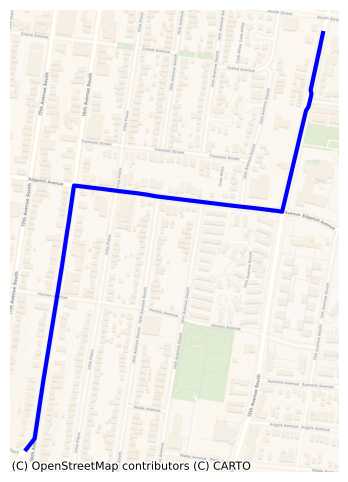

In [1]:
import requests
import json
import geopandas as gpd
from shapely.geometry import LineString, Polygon, Point
import contextily as ctx
import matplotlib.pyplot as plt

def plot_route_coords(route_coords):
    # Create a GeoDataFrame from route_coords
    route_line = LineString([(lon, lat) for lat, lon in route_coords])
    gdf = gpd.GeoDataFrame({'geometry': [route_line]}, crs='EPSG:4326')

    # Convert to Web Mercator for contextily
    gdf_webmerc = gdf.to_crs(epsg=3857)

    # Plot
    fig, ax = plt.subplots(figsize=(10, 6))
    gdf_webmerc.plot(ax=ax, linewidth=3, color='blue')

    ctx.add_basemap(ax,
                source=ctx.providers.CartoDB.Voyager)
    ax.set_axis_off()
    return ax

# Example coordinates: [latitude, longitude]
locations = [
    {"lat": 36.13708608202356, "lon": -86.79454842827164},  # Origin
    {"lat": 36.14703876277182, "lon": -86.7858962286902}    # Destination
]

exclude_locations = [
    {"lat": 36.14329812454997, "lon": -86.79260387916997}  # Example location to exclude
]

url = "http://localhost:8002/route"
headers = {"Content-Type": "application/json"}
payload = {
    "locations": locations,
    "costing": "auto",
    "directions_options": {"units": "kilometers"},
    "format": "osrm",
    "shape_format": "geojson"
}

response = requests.post(url, headers=headers, data=json.dumps(payload))
result = response.json()

# # Print turn-by-turn instructions
# for maneuver in result['trip']['legs'][0]['maneuvers']:
#     print(maneuver['instruction'])
# get the route via coordinates
route_coords = [(point[1], point[0]) for point in result['routes'][0]['geometry']['coordinates']]
ax = plot_route_coords(route_coords)

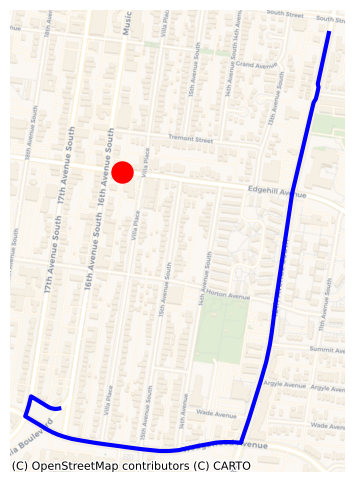

In [2]:
# Example coordinates: [latitude, longitude]
locations = [
    {"lat": 36.13708608202356, "lon": -86.79454842827164},  # Origin
    {"lat": 36.14703876277182, "lon": -86.7858962286902}    # Destination
]

exclude_locations = [
    {"lat": 36.14329812454997, "lon": -86.79260387916997}  # Example location to exclude
]

url = "http://localhost:8002/route"
headers = {"Content-Type": "application/json"}
payload = {
    "locations": locations,
    "costing": "auto",
    "directions_options": {"units": "kilometers"},
    "format": "osrm",
    "shape_format": "geojson",
    "exclude_locations": exclude_locations
}

response = requests.post(url, headers=headers, data=json.dumps(payload))
result = response.json()

# # Print turn-by-turn instructions
# for maneuver in result['trip']['legs'][0]['maneuvers']:
#     print(maneuver['instruction'])
# get the route via coordinates
route_coords = [(point[1], point[0]) for point in result['routes'][0]['geometry']['coordinates']]
ax = plot_route_coords(route_coords)

exclude_polygon = Point(exclude_locations[0]['lon'], exclude_locations[0]['lat'])
exclude_gdf = gpd.GeoDataFrame({'geometry': [exclude_polygon]}, crs='EPSG:4326')
exclude_gdf_webmerc = exclude_gdf.to_crs(epsg=3857)
exclude_gdf_webmerc.plot(ax=ax, facecolor='red', edgecolor='red', linewidth=2, markersize=200,)
plt.show()

<Axes: >

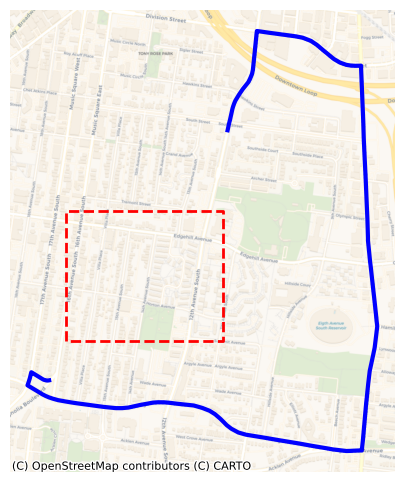

In [3]:
# Example coordinates: [latitude, longitude]
locations = [
    {"lat": 36.13708608202356, "lon": -86.79454842827164},  # Origin
    {"lat": 36.14703876277182, "lon": -86.7858962286902}    # Destination
]

exclude_locations = [
    {"lat": 36.14329812454997, "lon": -86.79260387916997}  # Example location to exclude
]

exclude_polygon = [
        [
        [
            -86.79381460717822,
            36.143851030329714
        ],
        [
            -86.79381460717822,
            36.138652589633196
        ],
        [
            -86.78604216606114,
            36.138652589633196
        ],
        [
            -86.78604216606114,
            36.143851030329714
        ],
        [
            -86.79381460717822,
            36.143851030329714
        ]
        ]
    ]

url = "http://localhost:8002/route"
headers = {"Content-Type": "application/json"}
payload = {
    "locations": locations,
    "costing": "auto",
    "directions_options": {"units": "kilometers"},
    "format": "osrm",
    "shape_format": "geojson",
    "exclude_polygons": exclude_polygon
}

response = requests.post(url, headers=headers, data=json.dumps(payload))
result = response.json()

# # Print turn-by-turn instructions
# for maneuver in result['trip']['legs'][0]['maneuvers']:
#     print(maneuver['instruction'])
# get the route via coordinates
route_coords = [(point[1], point[0]) for point in result['routes'][0]['geometry']['coordinates']]
ax = plot_route_coords(route_coords)
# Plot the exclude polygon on the same axes
exclude_poly_coords = payload["exclude_polygons"][0]
ep = Polygon(exclude_poly_coords)
exclude_gdf = gpd.GeoDataFrame({'geometry': [ep]}, crs='EPSG:4326')
exclude_gdf_webmerc = exclude_gdf.to_crs(epsg=3857)
exclude_gdf_webmerc.plot(ax=ax, facecolor='none', edgecolor='red', linewidth=2, linestyle='--')


# Effect on cost matrix

In [4]:
# Prepare payload for cost matrix request
cost_matrix_payload = {
    "sources": [locations[0]],  # Index of origin(s)
    "targets": [locations[1]],   # Index of destination(s)
    "costing":"auto",
}

print(cost_matrix_payload)
cost_matrix_url = url.replace("/route", "/sources_to_targets")
print(cost_matrix_url)
cost_matrix_response = requests.post(cost_matrix_url, headers=headers, data=json.dumps(cost_matrix_payload))
cost_matrix_result = cost_matrix_response.json()

print(cost_matrix_result['sources_to_targets'])


{'sources': [{'lat': 36.13708608202356, 'lon': -86.79454842827164}], 'targets': [{'lat': 36.14703876277182, 'lon': -86.7858962286902}], 'costing': 'auto'}
http://localhost:8002/sources_to_targets
[[{'distance': 1.759, 'time': 151, 'to_index': 0, 'from_index': 0}]]


In [5]:
# Prepare payload for cost matrix request
cost_matrix_payload = {
    "sources": [locations[0]],  # Index of origin(s)
    "targets": [locations[1]],   # Index of destination(s)
    "costing":"auto",
    "exclude_locations": exclude_locations
}

print(cost_matrix_payload)
cost_matrix_url = url.replace("/route", "/sources_to_targets")
print(cost_matrix_url)
cost_matrix_response = requests.post(cost_matrix_url, headers=headers, data=json.dumps(cost_matrix_payload))
cost_matrix_result = cost_matrix_response.json()
print(cost_matrix_result['sources_to_targets'])


{'sources': [{'lat': 36.13708608202356, 'lon': -86.79454842827164}], 'targets': [{'lat': 36.14703876277182, 'lon': -86.7858962286902}], 'costing': 'auto', 'exclude_locations': [{'lat': 36.14329812454997, 'lon': -86.79260387916997}]}
http://localhost:8002/sources_to_targets
[[{'distance': 2.057, 'time': 174, 'to_index': 0, 'from_index': 0}]]


In [6]:
# Prepare payload for cost matrix request
cost_matrix_payload = {
    "sources": [locations[0]],  # Index of origin(s)
    "targets": [locations[1]],   # Index of destination(s)
    "costing":"auto",
    "exclude_polygons": exclude_polygon
}

print(cost_matrix_payload)
cost_matrix_url = url.replace("/route", "/sources_to_targets")
print(cost_matrix_url)
cost_matrix_response = requests.post(cost_matrix_url, headers=headers, data=json.dumps(cost_matrix_payload))
cost_matrix_result = cost_matrix_response.json()

print(cost_matrix_result['sources_to_targets'])

{'sources': [{'lat': 36.13708608202356, 'lon': -86.79454842827164}], 'targets': [{'lat': 36.14703876277182, 'lon': -86.7858962286902}], 'costing': 'auto', 'exclude_polygons': [[[-86.79381460717822, 36.143851030329714], [-86.79381460717822, 36.138652589633196], [-86.78604216606114, 36.138652589633196], [-86.78604216606114, 36.143851030329714], [-86.79381460717822, 36.143851030329714]]]}
http://localhost:8002/sources_to_targets
[[{'distance': 4.439, 'time': 345, 'to_index': 0, 'from_index': 0}]]
